<h3><b>1. Import Libraries and Load the Raw Dataset <b><h3>

In [37]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "data" / "raw" / "concrete_data.csv").exists()
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "concrete_data.csv"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


data = pd.read_csv(RAW_DATA_PATH)

print(f"Raw dataset shape: {data.shape}")
data.head()

Raw dataset shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


<h3><b>2. Standardize Column Names and Data Types <b><h3>

In [38]:
data.columns = data.columns.str.strip()

data.rename(
    columns={
        "concrete_compressive_strength": "compressive_strength"
    },
    inplace=True,
)

expected_columns = [
    "cement",
    "blast_furnace_slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age",
    "compressive_strength",
]

if list(data.columns) != expected_columns:
    raise ValueError(f"Unexpected columns: {data.columns.tolist()}")

data[expected_columns] = data[expected_columns].apply(
    pd.to_numeric,
    errors="raise",
)

print(data.dtypes)

cement                  float64
blast_furnace_slag      float64
fly_ash                 float64
water                   float64
superplasticizer        float64
coarse_aggregate        float64
fine_aggregate          float64
age                       int64
compressive_strength    float64
dtype: object


<h3><b>3. Remove Missing and Duplicate Rows <b><h3>

In [39]:
print("Missing values:")
print(data.isna().sum())

print("Duplicate rows:", data.duplicated().sum())

data = data.dropna().drop_duplicates().reset_index(drop=True)

print(f"Cleaned dataset shape: {data.shape}")
print(f"Missing values after cleaning: {int(data.isna().sum().sum())}")
print(f"Duplicate rows after cleaning: {int(data.duplicated().sum())}")

Missing values:
cement                  0
blast_furnace_slag      0
fly_ash                 0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
dtype: int64
Duplicate rows: 25
Cleaned dataset shape: (1005, 9)
Missing values after cleaning: 0
Duplicate rows after cleaning: 0


In [32]:
print(f"Rows after duplicate removal: {data.shape[0]}")
print(f"Features after duplicate removal: {data.shape[1] - 1}")
print(f"Total columns after duplicate removal: {data.shape[1]}")
print(f"Dataset shape after duplicate removal: {data.shape}")

Rows after duplicate removal: 1005
Features after duplicate removal: 8
Total columns after duplicate removal: 9
Dataset shape after duplicate removal: (1005, 9)


<h3><b>3.1. Check Skewness <b><h3>

In [33]:
skewness = data.skew(numeric_only=True).sort_values(ascending=False)

print("Skewness of each numeric column:")
print(skewness)

print("\nStrongly skewed columns (absolute skewness > 1):")
print(skewness[skewness.abs() > 1])

Skewness of each numeric column:
age                     3.253974
superplasticizer        0.980604
blast_furnace_slag      0.855225
cement                  0.564959
fly_ash                 0.497231
compressive_strength    0.395696
water                   0.034433
coarse_aggregate       -0.065256
fine_aggregate         -0.252353
dtype: float64

Strongly skewed columns (absolute skewness > 1):
age    3.253974
dtype: float64


<h3><b>3.2. Correlation Analysis <b><h3>

Correlation with compressive strength:
compressive_strength    1.000000
cement                  0.488283
superplasticizer        0.344209
age                     0.337367
blast_furnace_slag      0.103374
fly_ash                -0.080648
coarse_aggregate       -0.144717
fine_aggregate         -0.186448
water                  -0.269624
Name: compressive_strength, dtype: float64


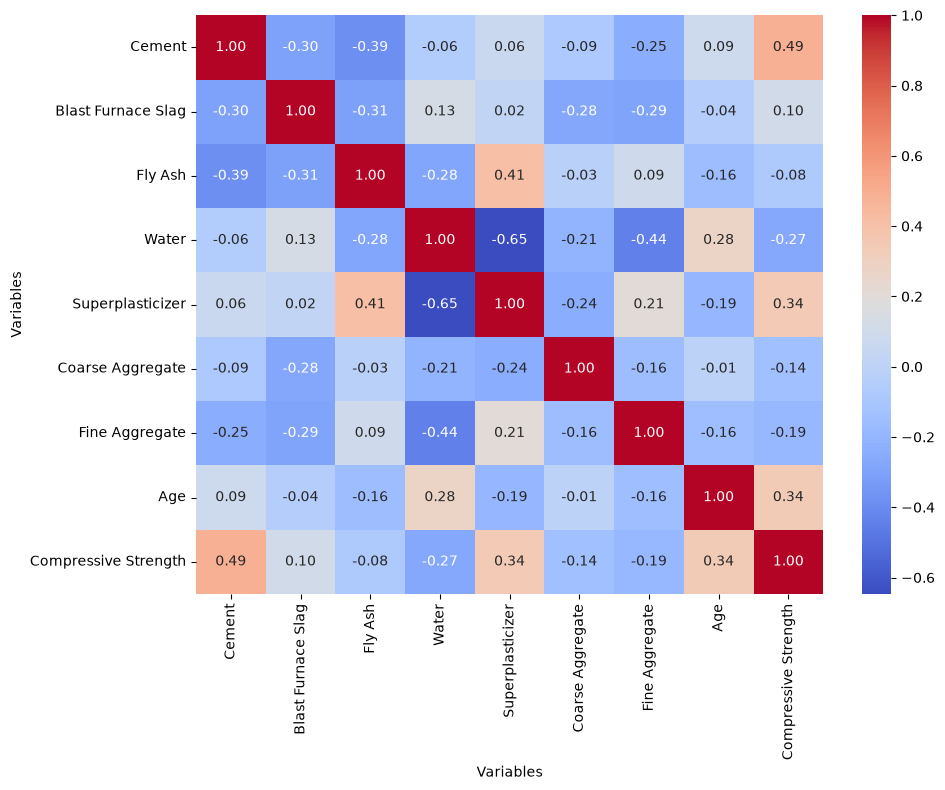

In [34]:
correlation_matrix = data.corr(numeric_only=True)

print("Correlation with compressive strength:")
print(correlation_matrix["compressive_strength"].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=[column.replace("_", " ").title() for column in correlation_matrix.columns],
    yticklabels=[column.replace("_", " ").title() for column in correlation_matrix.index],
)
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "preprocessing_correlation_heatmap.png", dpi=300)
plt.show()
plt.close()

<h3><b>4. Split Data into 80% Training and 20% Testing <b><h3>

In [40]:
from sklearn.model_selection import train_test_split


target_column = "compressive_strength"
X = data.drop(columns=[target_column])
y = data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_test_before_scaling = X_test.copy()

test_size = len(X_test) / len(X)
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")
print(f"Test set proportion: {test_size:.1%}")

Training features shape: (804, 8)
Test features shape: (201, 8)
Training target shape: (804,)
Test target shape: (201,)
Test set proportion: 20.0%


<h3><b>5. Scale Features for Linear Models <b><h3>

In [42]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.testing.assert_frame_equal(X_test, X_test_before_scaling)

print(f"Scaled training features shape: {X_train_scaled.shape}")
print(f"Scaled test features shape: {X_test_scaled.shape}")
print("Original test set remains unchanged.")

processed_path = PROJECT_ROOT / "data" / "processed" / "concrete_data_cleaned.csv"
processed_path.parent.mkdir(parents=True, exist_ok=True)
data.to_csv(processed_path, index=False)

print(f"Cleaned dataset saved to: {processed_path}")

Scaled training features shape: (804, 8)
Scaled test features shape: (201, 8)
Original test set remains unchanged.
Cleaned dataset saved to: d:\My Projects\Concrete-Compressive-Strength-Predictor\data\processed\concrete_data_cleaned.csv
